In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [22]:
N_particles = 500

import matplotlib as mpl

In [ ]:
# ---- STILE PAPER ----
mpl.rcParams.update({

    # Usa font LaTeX (coerente con paper)
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Dimensioni testo (standard journal)
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Spessori ottimizzati per stampa
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Tick dentro (stile PRL/JCP)
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    # Griglia molto leggera
    "grid.linestyle": ":",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.5,

    # Legenda minimale
    "legend.frameon": False,
})

In [24]:
def autocorrelation_time(data, max_lag=None):

    data = np.asarray(data)
    N = len(data)

    if max_lag is None:
        max_lag = N // 2

    mean = np.mean(data)
    var = np.var(data)

    if var == 0:
        return 0.0

    autocorr = []

    for t in range(max_lag):
        c = np.mean((data[:N - t] - mean) * (data[t:] - mean)) / var
        autocorr.append(c)

    autocorr = np.array(autocorr)

    # sum until autocorrelation is positive
    positive = autocorr[1:][autocorr[1:] > 0]

    tau = 0.5 + np.sum(positive)
    return tau


152
-6.022923059805137
0.0022133558906048518
129
-5.51162563680008
0.0017958838714798937
441.7568802564939
-0.07120791180588017
2.8880618425030117e-05
956.0878253148317
-0.009843705854161777
1.094975123757358e-05


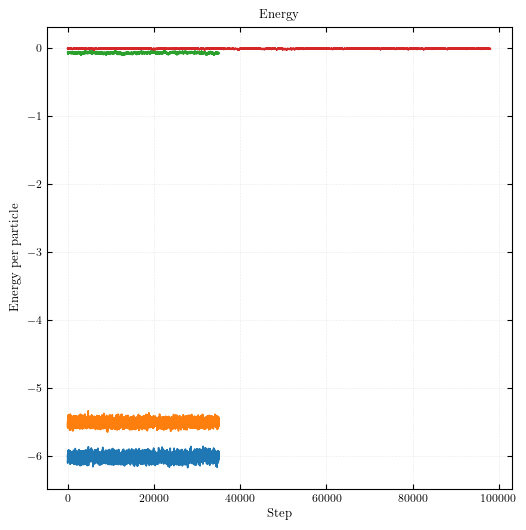

In [25]:
# Plot
plt.figure(figsize=(6, 6))

# 1
energy = np.loadtxt("./T0.85p0.86/energy.csv", delimiter=";")  # 0.42 acc rate
energy = energy[70000:] - 0.26*500
plt.plot(energy/N_particles)

tau = int(autocorrelation_time(energy))
print(tau)
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(2*tau/100000))


# 2
energy = np.loadtxt("./T0.85p0.776/energy.csv", delimiter=";")  # 0.50 acc rate
energy = energy[70000:]-120
plt.plot(energy/N_particles)

tau = int(autocorrelation_time(energy))
print(tau)
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(2*tau/100000))


# 3
energy = np.loadtxt("./T0.85p0.007/energy.csv", delimiter=";")  # 0.99 acc rate
energy = energy[70000:]-1.0854
plt.plot(energy/N_particles)

print(autocorrelation_time(energy))
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(1/100000))

# 4
energy = np.loadtxt("./T0.85p0.001/energy.csv", delimiter=";")  # 0.42 acc rate
energy = energy[7000:] - 0.155069
plt.plot(energy/N_particles)

print(autocorrelation_time(energy))
print(np.mean(energy/N_particles))
print(np.std(energy/N_particles)*np.sqrt(1/100000))

plt.title("Energy")
plt.grid(True)
plt.ylabel("Energy per particle")
plt.xlabel("Step")
plt.show()

data = np.loadtxt("output/specific_heat.csv", delimiter=";")
T = data[:,0]
CV = data[:,1]
# Plot
plt.figure(figsize=(6, 6))
plt.plot(T,CV, "-o")

plt.title("")
plt.grid(True)
plt.xlabel("T")
plt.ylabel("Cv")
plt.show()

In [26]:
def LJ_pot(x):
    return np.pow(x,-12) - np.pow(x,-6)

x = np.linspace(0.1,20,10000)
y = LJ_pot(x)


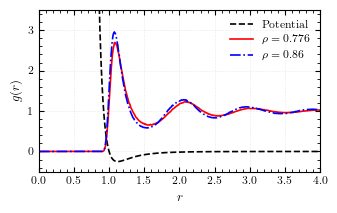

In [27]:
fig, ax = plt.subplots(figsize=(3.4, 2.2))  

# Potential
ax.plot(x, y,
        color="black",
        linestyle="--",
        label="Potential")

# First dataset
data = np.loadtxt("./T0.85p0.776/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="r",
        linestyle="-",
        label=r"$\rho = 0.776$")

# Second dataset
data = np.loadtxt("./T0.85p0.86/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="b",
        linestyle="-.",
        label=r"$\rho = 0.86$")

# ---- Assi ----
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$g(r)$")

ax.set_xlim(0, 4)
ax.set_ylim(-0.5, 3.5)

ax.minorticks_on()

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("g2.pdf")
plt.show()

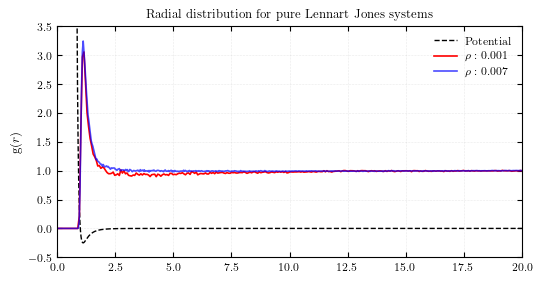

In [28]:
# Plot
plt.figure(figsize=(6, 3))

plt.plot(x,y, color='black',
    linestyle='--',
    linewidth=1,label="Potential")

data = np.loadtxt("./T0.85p0.001/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1]*2, c="r", label=r"$\rho: 0.001$")

data = np.loadtxt("./T0.85p0.007/radial_distribution.csv", delimiter=";")
plt.plot(data[:,0], data[:,1]*2, c="b", label=r"$\rho: 0.007$", alpha=0.7)

plt.title(r"Radial distribution for pure Lennart Jones systems  ")
plt.ylabel("g($r$)")
plt.legend()
plt.xlim([0,20])
plt.ylim([-0.5,3.5])
plt.grid(True)

plt.savefig("g1.pdf", bbox_inches="tight")

plt.show()

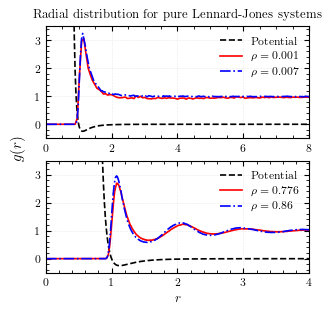

In [29]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 1.6*2),   # ~ doppia colonna (PRL standard)
    sharey=True           # stessa scala verticale
)

fig.subplots_adjust(hspace=0.2) 

ax = axes[0]

ax.set_title(r"Radial distribution for pure Lennard-Jones systems  ")

# Potential
ax.plot(x, y,
        color="black",
        linestyle="--",
        label="Potential")

# First dataset
data = np.loadtxt("./T0.85p0.001/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="r",
        linestyle="-",
        label=r"$\rho = 0.001$")

# Second dataset
data = np.loadtxt("./T0.85p0.007/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="b",
        linestyle="-.",
        label=r"$\rho = 0.007$")

# ---- Assi ----
#ax.set_ylabel(r"$g(r)$")

ax.set_xlim(0, 8)
ax.set_ylim(-0.5, 3.5)

ax.minorticks_on()

ax.legend()
ax.grid(True)

ax = axes[1]

# Potential
ax.plot(x, y,
        color="black",
        linestyle="--",
        label="Potential")

# First dataset
data = np.loadtxt("./T0.85p0.776/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="r",
        linestyle="-",
        label=r"$\rho = 0.776$")

# Second dataset
data = np.loadtxt("./T0.85p0.86/radial_distribution.csv", delimiter=";")
ax.plot(data[:,0], data[:,1]*2,
        color="b",
        linestyle="-.",
        label=r"$\rho = 0.86$")

# ---- Assi ----
ax.set_xlabel(r"$r$")
#ax.set_ylabel(r"$g(r)$")

ax.set_xlim(0, 4)
ax.set_ylim(-0.5, 3.5)

ax.minorticks_on()

ax.legend()
ax.grid(True)

fig.supylabel(r"$g(r)$") # ylabel in common

plt.savefig("g_dual_plot.pdf")
plt.show()

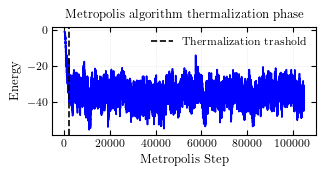

In [30]:
data = np.loadtxt("./T0.85p0.007/energy.csv", delimiter=";")

fig, axes = plt.subplots(figsize=(3.4, (1.4)))

plt.plot(data - 1.08,ms=4,color="blue")
plt.grid()
plt.title("Metropolis algorithm thermalization phase")
plt.ylabel("Energy")
plt.xlabel("Metropolis Step")
plt.axvline(x=2000, c="k", ls="--", label="Thermalization trashold")

plt.legend()

plt.savefig("equilibrization.pdf", bbox_inches="tight")